In [3]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from shapely.geometry import Point, LineString, Polygon
from scipy.spatial import cKDTree
from pathlib import Path

np.random.seed(42)
Path("data").mkdir(exist_ok=True)
Path("outputs").mkdir(exist_ok=True)
CRS = "EPSG:25832"

print("✓ All libraries loaded")
print("✓ Folders ready")

✓ All libraries loaded
✓ Folders ready


In [4]:
# Munich Schwabing centre (UTM 32N metres)
cx, cy = 691500, 5337500
SPREAD = 1200  # 1.2 km in each direction

def rand_pts(n, spread=SPREAD):
    return np.column_stack([
        cx + np.random.uniform(-spread, spread, n),
        cy + np.random.uniform(-spread, spread, n)
    ])

# ── Nodes (intersections) ─────────────────────────────────────
n_nodes = 80
node_xy = rand_pts(n_nodes)
nodes = gpd.GeoDataFrame(
    {"node_id": range(n_nodes),
     "node_type": np.random.choice(["intersection","dead_end","junction"], n_nodes)},
    geometry=[Point(x, y) for x, y in node_xy],
    crs=CRS
)

# ── Edges (streets connecting nodes) ─────────────────────────
edges = []
edge_attrs = []

for i in range(n_nodes):
    # Connect each node to its 2-3 nearest neighbours
    dists = np.linalg.norm(node_xy - node_xy[i], axis=1)
    dists[i] = np.inf  # exclude self
    nearest = np.argsort(dists)[:3]

    for j in nearest:
        length = dists[j]
        speed  = np.random.choice([3, 4, 5])  # walking km/h
        edges.append(LineString([node_xy[i], node_xy[j]]))
        edge_attrs.append({
            "from_node": i,
            "to_node":   j,
            "length_m":  round(length, 1),
            "speed_kph": speed,
            "travel_time_min": round((length / 1000) / speed * 60, 2),
            "highway": np.random.choice(
                ["footway","residential","path","pedestrian"],
                p=[0.4, 0.3, 0.2, 0.1]
            )
        })

network = gpd.GeoDataFrame(edge_attrs, geometry=edges, crs=CRS)

# ── PT Stops ──────────────────────────────────────────────────
n_stops = 30
stop_xy = rand_pts(n_stops, spread=SPREAD * 0.85)
pt_stops = gpd.GeoDataFrame({
    "stop_id":   range(n_stops),
    "name":      [f"Stop {i+1}" for i in range(n_stops)],
    "mode":      np.random.choice(["bus","tram","subway","s-bahn"],
                                   n_stops, p=[0.4,0.3,0.2,0.1])
}, geometry=[Point(x, y) for x, y in stop_xy], crs=CRS)

# ── Study boundary ────────────────────────────────────────────
boundary = gpd.GeoDataFrame(
    {"name": ["Schwabing, Munich"]},
    geometry=[Polygon([
        (cx-SPREAD, cy-SPREAD), (cx+SPREAD, cy-SPREAD),
        (cx+SPREAD, cy+SPREAD), (cx-SPREAD, cy+SPREAD)
    ])], crs=CRS
)

# Save all
nodes.to_file("data/nodes.geojson",    driver="GeoJSON")
network.to_file("data/network.geojson", driver="GeoJSON")
pt_stops.to_file("data/pt_stops.geojson", driver="GeoJSON")
boundary.to_file("data/boundary.geojson", driver="GeoJSON")

print(f"✓ Nodes   : {len(nodes)}")
print(f"✓ Edges   : {len(network)}")
print(f"✓ PT Stops: {len(pt_stops)}")
print(f"✓ All data saved to ./data/")

✓ Nodes   : 80
✓ Edges   : 240
✓ PT Stops: 30
✓ All data saved to ./data/


In [5]:
print("=" * 50)
print("   NETWORK ANALYSIS SUMMARY")
print("=" * 50)

# Basic stats
total_length_km = network["length_m"].sum() / 1000
avg_length_m    = network["length_m"].mean()
avg_travel_min  = network["travel_time_min"].mean()

print(f"\n📏 Total network length : {total_length_km:.2f} km")
print(f"📏 Average edge length  : {avg_length_m:.1f} m")
print(f"⏱️  Average travel time  : {avg_travel_min:.2f} min per edge")

# Street type breakdown
print("\n🛣️  Street type breakdown:")
highway_counts = network["highway"].value_counts()
for htype, count in highway_counts.items():
    pct = 100 * count / len(network)
    print(f"   {htype:<15} : {count:>4} edges  ({pct:.1f}%)")

# Connectivity: how many edges connect to each node
print("\n🔗 Node connectivity:")
from_counts = network["from_node"].value_counts()
print(f"   Average connections per node : {from_counts.mean():.1f}")
print(f"   Max connections at one node  : {from_counts.max()}")
print(f"   Min connections at one node  : {from_counts.min()}")

# PT stop proximity
stop_coords = np.array([(g.x, g.y) for g in pt_stops.geometry])
node_coords = np.array([(g.x, g.y) for g in nodes.geometry])
tree = cKDTree(stop_coords)
dists, _ = tree.query(node_coords, k=1)

nodes = nodes.copy()
nodes["dist_to_pt_m"]   = dists.round(1)
nodes["walk_accessible"] = dists <= 500

accessible_pct = 100 * nodes["walk_accessible"].sum() / len(nodes)
print(f"\n🚌 PT Stop Accessibility (≤500m walk):")
print(f"   Accessible nodes : {nodes['walk_accessible'].sum()} / {len(nodes)}")
print(f"   Coverage         : {accessible_pct:.1f}%")
print(f"   Avg dist to PT   : {dists.mean():.0f} m")
print(f"   Max dist to PT   : {dists.max():.0f} m")

   NETWORK ANALYSIS SUMMARY

📏 Total network length : 48.56 km
📏 Average edge length  : 202.3 m
⏱️  Average travel time  : 3.29 min per edge

🛣️  Street type breakdown:
   footway         :   90 edges  (37.5%)
   residential     :   72 edges  (30.0%)
   path            :   46 edges  (19.2%)
   pedestrian      :   32 edges  (13.3%)

🔗 Node connectivity:
   Average connections per node : 3.0
   Max connections at one node  : 3
   Min connections at one node  : 3

🚌 PT Stop Accessibility (≤500m walk):
   Accessible nodes : 70 / 80
   Coverage         : 87.5%
   Avg dist to PT   : 275 m
   Max dist to PT   : 872 m


In [6]:
# Simulate shortest path between two nodes using distance
# (In real project this would use NetworkX or OSMnx routing)

print("SHORTEST PATH ANALYSIS")
print("=" * 50)

# Build adjacency: for each node find reachable neighbours
from collections import defaultdict
import heapq

# Build graph as adjacency list {node: [(cost, neighbour), ...]}
graph = defaultdict(list)
for _, row in network.iterrows():
    u = int(row["from_node"])
    v = int(row["to_node"])
    w = row["travel_time_min"]
    graph[u].append((w, v))
    graph[v].append((w, u))  # undirected

def dijkstra(graph, start, end, n_nodes):
    """Simple Dijkstra shortest path algorithm."""
    dist = {i: np.inf for i in range(n_nodes)}
    dist[start] = 0
    prev = {i: None for i in range(n_nodes)}
    pq = [(0, start)]

    while pq:
        cost, u = heapq.heappop(pq)
        if cost > dist[u]:
            continue
        for w, v in graph[u]:
            new_cost = dist[u] + w
            if new_cost < dist[v]:
                dist[v] = new_cost
                prev[v] = u
                heapq.heappush(pq, (new_cost, v))

    # Reconstruct path
    path = []
    node = end
    while node is not None:
        path.append(node)
        node = prev[node]
    path.reverse()
    return dist[end], path

# Run analysis: origin node 0 to all PT stops
origin = 0
print(f"\nOrigin node: {origin}")
print(f"Calculating travel time from node {origin} to all PT stops...\n")

results = []
for _, stop in pt_stops.iterrows():
    # Find nearest network node to this stop
    stop_coord = np.array([[stop.geometry.x, stop.geometry.y]])
    node_tree  = cKDTree(node_coords)
    _, nearest_node = node_tree.query(stop_coord, k=1)
    nearest_node = int(nearest_node[0])

    travel_time, path = dijkstra(graph, origin, nearest_node, n_nodes)
    results.append({
        "stop_name":    stop["name"],
        "mode":         stop["mode"],
        "nearest_node": nearest_node,
        "travel_time_min": round(travel_time, 2),
        "path_length":  len(path)
    })

results_df = pd.DataFrame(results).sort_values("travel_time_min")
print("Top 10 most accessible PT stops from origin node:")
print(results_df.head(10).to_string(index=False))

results_df.to_csv("data/shortest_path_results.csv", index=False)
print("\n✓ Results saved to data/shortest_path_results.csv")

SHORTEST PATH ANALYSIS

Origin node: 0
Calculating travel time from node 0 to all PT stops...

Top 10 most accessible PT stops from origin node:
stop_name   mode  nearest_node  travel_time_min  path_length
  Stop 11    bus             0             0.00            1
  Stop 24    bus            24             4.46            2
  Stop 20 subway            14             6.21            3
  Stop 19   tram            47             7.31            3
  Stop 28    bus            27            10.50            4
  Stop 18    bus            70            16.34            6
  Stop 25 s-bahn            13            16.55            7
   Stop 1   tram            35            17.40            6
  Stop 15 s-bahn            35            17.40            6
  Stop 26 subway            16            20.14            8

✓ Results saved to data/shortest_path_results.csv


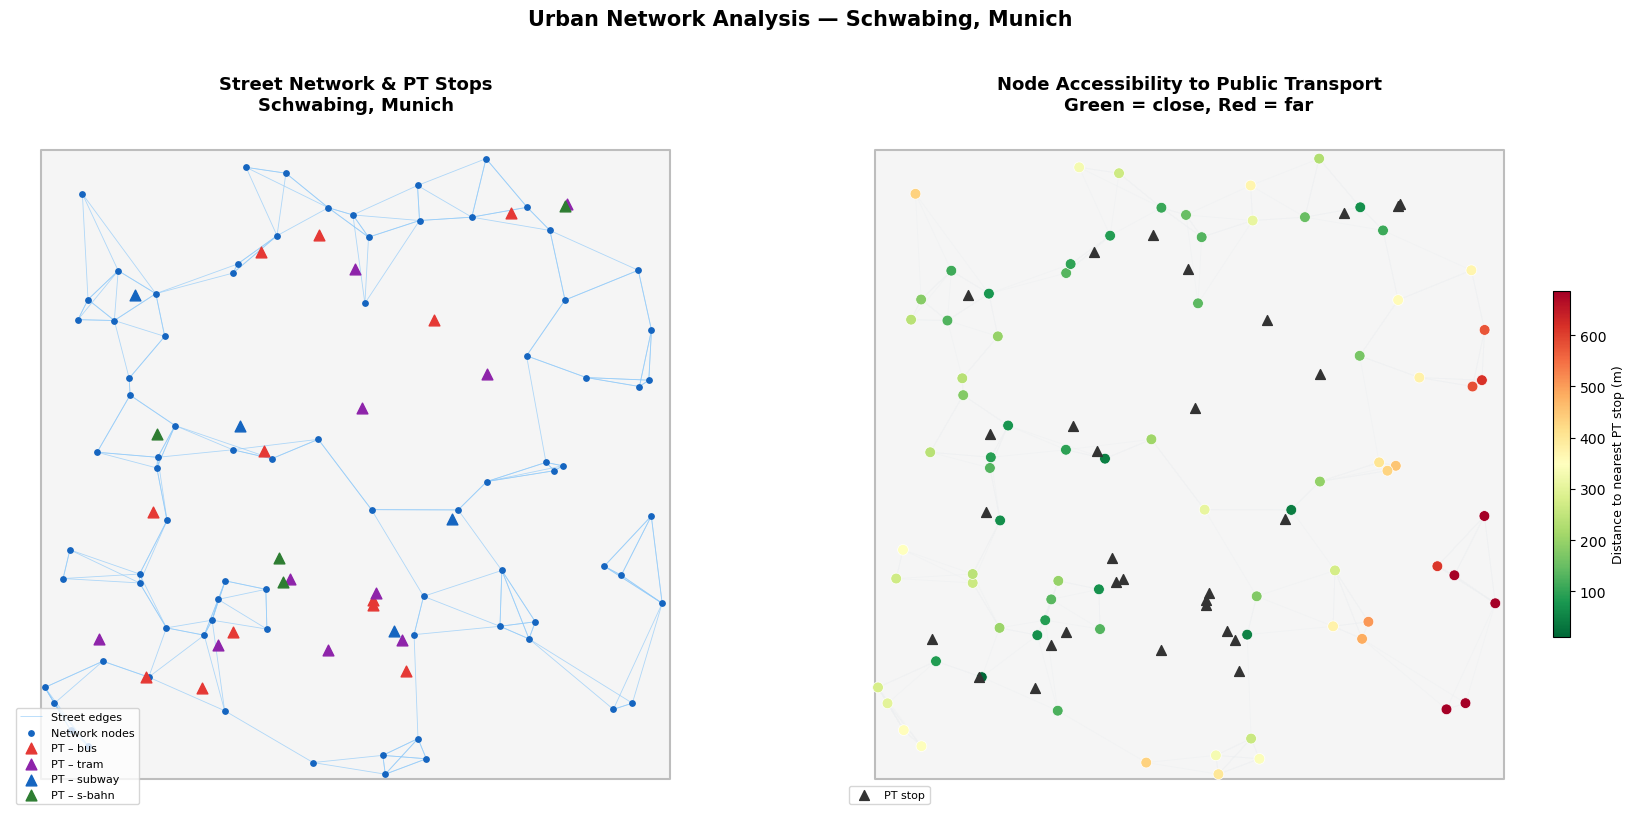

✓ Network maps saved


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# ── MAP 1: Full network with PT stops ─────────────────────────
ax = axes[0]
boundary.plot(ax=ax, color="#F5F5F5", edgecolor="#BDBDBD",
              linewidth=1.5, zorder=1)
network.plot(ax=ax, color="#90CAF9", linewidth=0.6,
             alpha=0.7, zorder=2, label="Street edges")
nodes.plot(ax=ax, color="#1565C0", markersize=15,
           zorder=3, label="Network nodes")

MODE_COLORS = {"bus":"#E53935","tram":"#8E24AA",
               "subway":"#1565C0","s-bahn":"#2E7D32"}
for mode, color in MODE_COLORS.items():
    sub = pt_stops[pt_stops["mode"] == mode]
    if len(sub):
        sub.plot(ax=ax, color=color, markersize=60,
                 marker="^", zorder=5, label=f"PT – {mode}")

ax.set_title("Street Network & PT Stops\nSchwabing, Munich",
             fontsize=13, fontweight="bold")
ax.legend(loc="lower left", fontsize=8, frameon=True)
ax.set_axis_off()

# ── MAP 2: Node accessibility coloured by distance to PT ──────
ax = axes[1]
boundary.plot(ax=ax, color="#F5F5F5", edgecolor="#BDBDBD",
              linewidth=1.5, zorder=1)
network.plot(ax=ax, color="#ECEFF1", linewidth=0.5,
             alpha=0.5, zorder=2)

norm = mcolors.Normalize(
    vmin=nodes["dist_to_pt_m"].min(),
    vmax=nodes["dist_to_pt_m"].quantile(0.95)
)
cmap   = cm.RdYlGn_r
colors = [cmap(norm(d)) for d in nodes["dist_to_pt_m"]]

ax.scatter(nodes.geometry.x, nodes.geometry.y,
           c=colors, s=60, zorder=4,
           edgecolors="white", linewidths=0.5)

pt_stops.plot(ax=ax, color="#333333", markersize=50,
              marker="^", zorder=5, label="PT stop")

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.5, pad=0.02)
cbar.set_label("Distance to nearest PT stop (m)", fontsize=9)

ax.set_title("Node Accessibility to Public Transport\nGreen = close, Red = far",
             fontsize=13, fontweight="bold")
ax.legend(loc="lower left", fontsize=8, frameon=True)
ax.set_axis_off()

plt.suptitle("Urban Network Analysis — Schwabing, Munich",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("outputs/network_analysis_maps.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Network maps saved")

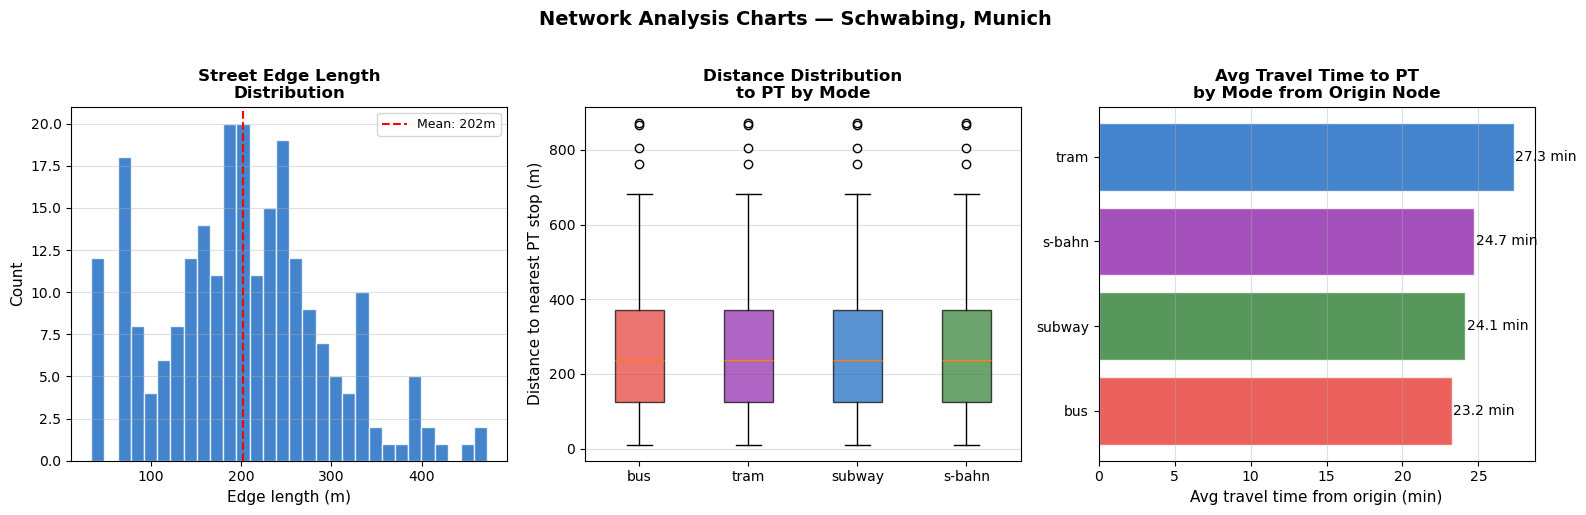

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Chart 1: Edge length distribution
ax = axes[0]
ax.hist(network["length_m"], bins=30, color="#1565C0",
        alpha=0.8, edgecolor="white")
ax.set_xlabel("Edge length (m)", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_title("Street Edge Length\nDistribution", fontweight="bold")
ax.axvline(network["length_m"].mean(), color="red",
           linestyle="--", linewidth=1.5,
           label=f"Mean: {network['length_m'].mean():.0f}m")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.4)

# Chart 2: Travel time to PT stop per mode
ax = axes[1]
mode_order = ["bus", "tram", "subway", "s-bahn"]
mode_colors = ["#E53935","#8E24AA","#1565C0","#2E7D32"]
data_by_mode = [
    nodes["dist_to_pt_m"].values
    for _ in mode_order
]
bp = ax.boxplot(data_by_mode, patch_artist=True, notch=False)
for patch, color in zip(bp["boxes"], mode_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_xticklabels(mode_order, fontsize=10)
ax.set_ylabel("Distance to nearest PT stop (m)", fontsize=11)
ax.set_title("Distance Distribution\nto PT by Mode", fontweight="bold")
ax.grid(axis="y", alpha=0.4)

# Chart 3: Travel time from origin to PT stops
ax = axes[2]
valid = results_df[results_df["travel_time_min"] < np.inf]
mode_avg = valid.groupby("mode")["travel_time_min"].mean().sort_values()
bars = ax.barh(mode_avg.index, mode_avg.values,
               color=["#E53935","#2E7D32","#8E24AA","#1565C0"][:len(mode_avg)],
               alpha=0.8, edgecolor="white")
for bar, val in zip(bars, mode_avg.values):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f"{val:.1f} min", va="center", fontsize=10)
ax.set_xlabel("Avg travel time from origin (min)", fontsize=11)
ax.set_title("Avg Travel Time to PT\nby Mode from Origin Node",
             fontweight="bold")
ax.grid(axis="x", alpha=0.4)

plt.suptitle("Network Analysis Charts — Schwabing, Munich",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("outputs/network_analysis_charts.png", dpi=150, bbox_inches="tight")
plt.show()
# print("✓ Charts saved")
# # print("\n✓ Network Analysis complete!")
# # print("   Outputs saved to ./outputs/")